# Imports

## Import Libraries

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from torch.utils.tensorboard import SummaryWriter 
import json
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.manifold import spectral_embedding
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

## Import Dataset Classes

In [24]:
from dataset_classes import ISO_NE, ISO_NE_Small, AT, BD_Dataset, NCENT_Dataset, SH_Dataset, PL_Dataset, TN_Dataset

## Import Models

In [25]:
from models import GLFN_TC_Attention, GLFN_TC_GlobalLocal, GLFN_TC_GraphGRU, GLFN_TC_Linear, GLFN_TC_MultiScale

## Import Training and Testing Loops

In [26]:
from helper_functions_trial import train_model, test_model

# Main Function

## ISO_NE

### Linear

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics_with_raw_data/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 10 features (target=demand), total rows=103776
Raw data length: 103776
Scaler 'train_size' (raw rows): 62265
Scaler 'val_end' (raw rows): 83020
Total valid samples: 103464
Train samples: 62193, Val samples: 20755, Test samples: 20516

🚚 DataLoaders ready. Train batches: 972, Val batches: 325, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 972/972 [00:14<00:00, 65.66it/s, batch_loss=0.129]


Epoch 001 | Train Loss: 0.6916 | Val Loss: 0.3771 | LR: 0.000100
✅ New best model saved (Val Loss: 0.377135)


Epoch 2/100: 100%|██████████| 972/972 [00:12<00:00, 75.34it/s, batch_loss=0.0845]


Epoch 002 | Train Loss: 0.3172 | Val Loss: 0.3357 | LR: 0.000100
✅ New best model saved (Val Loss: 0.335657)


...

Epoch 069 | Train Loss: 0.1777 | Val Loss: 0.2036 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 70/100: 100%|██████████| 972/972 [00:12<00:00, 78.89it/s, batch_loss=0.0441]


Epoch 070 | Train Loss: 0.1778 | Val Loss: 0.2036 | LR: 0.000001
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_GLFN_TC_Linear_best_model.pth (Val Loss: 0.203567)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 252.96it/s]



Test Results:
MSE = 0.1806 | MAE = 0.3072 | R² = 0.8029

Test metrics logged to TensorBoard.


### Attention

In [7]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
    )


    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 10 features (target=demand), total rows=103776
Raw data length: 103776
Scaler 'train_size' (raw rows): 62265
Scaler 'val_end' (raw rows): 83020
Total valid samples: 103464
Train samples: 62193, Val samples: 20755, Test samples: 20516

🚚 DataLoaders ready. Train batches: 972, Val batches: 325, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 972/972 [00:12<00:00, 77.18it/s, batch_loss=0.114]


Epoch 001 | Train Loss: 1.5671 | Val Loss: 0.3650 | LR: 0.000100
✅ New best model saved (Val Loss: 0.365002)


Epoch 2/100: 100%|██████████| 972/972 [00:12<00:00, 77.96it/s, batch_loss=0.0821]


...

Epoch 078 | Train Loss: 0.1735 | Val Loss: 0.1943 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 79/100: 100%|██████████| 972/972 [00:12<00:00, 75.86it/s, batch_loss=0.0381]


Epoch 079 | Train Loss: 0.1739 | Val Loss: 0.1944 | LR: 0.000001
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_GLFN_TC_Attention_best_model.pth (Val Loss: 0.194341)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 245.03it/s]



Test Results:
MSE = 0.1713 | MAE = 0.2955 | R² = 0.8130

Test metrics logged to TensorBoard.


### GlobalLocal

In [8]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
    csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
    T_in=72,
    T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 10 features (target=demand), total rows=103776
Raw data length: 103776
Scaler 'train_size' (raw rows): 62265
Scaler 'val_end' (raw rows): 83020
Total valid samples: 103464
Train samples: 62193, Val samples: 20755, Test samples: 20516

🚚 DataLoaders ready. Train batches: 972, Val batches: 325, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 972/972 [00:13<00:00, 74.22it/s, batch_loss=0.0991]


Epoch 001 | Train Loss: 6.6448 | Val Loss: 0.3407 | LR: 0.000100
✅ New best model saved (Val Loss: 0.340741)


Epoch 2/100: 100%|██████████| 972/972 [00:12<00:00, 75.21it/s, batch_loss=0.0767]


...

Epoch 099 | Train Loss: 0.1678 | Val Loss: 0.1919 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 100/100: 100%|██████████| 972/972 [00:12<00:00, 76.07it/s, batch_loss=0.0317]


Epoch 100 | Train Loss: 0.1679 | Val Loss: 0.1918 | LR: 0.000001
✅ New best model saved (Val Loss: 0.191836)

Loading best model from Final_Run/ISO_NE_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.191836)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 243.96it/s]



Test Results:
MSE = 0.1698 | MAE = 0.2947 | R² = 0.8147

Test metrics logged to TensorBoard.


### Multi-Scale

In [5]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )
    
    # X_features = dataset.df_numeric.values.T  # Shape: (N, Total_Rows)

    # # 2. Construct Affinity Matrix (RBF Kernel)
    # # Gamma controls how "local" the similarity is. 
    # # A lower gamma means only very close features are connected.
    # # You can tune gamma (e.g., 1.0/N_features), or let sklearn handle defaults.
    # affinity_matrix = rbf_kernel(X_features, gamma=None) 

    # # 3. Spectral Embedding (The "Manifold" Step)
    # # This maps features into a low-dimensional space (n_components) based on graph connectivity
    # # Eigenvectors of the Laplacian matrix.
    # embeddings = spectral_embedding(
    #     affinity_matrix, 
    #     n_components=8,  # Dimensionality of the spectral space (tuneable, usually 4-10)
    #     norm_laplacian=True,
    #     drop_first=False
    # )

    # # 4. Hierarchical Clustering on Embeddings (The "Grouping" Step)
    # # We apply Ward's linkage on the spectral embeddings instead of raw data.
    # clustering = AgglomerativeClustering(
    #     n_clusters=5,      # Force 5 distinct communities
    #     metric='euclidean', # Euclidean distance in the *Spectral Space* is valid
    #     linkage='ward'
    # )
    # cluster_labels = clustering.fit_predict(embeddings)

    # # 5. Create Prior Adjacency Matrix
    # N_features = len(cluster_labels)
    # prior_adj_matrix = np.zeros((N_features, N_features))

    # for i in range(N_features):
    #     for j in range(N_features):
    #         if cluster_labels[i] == cluster_labels[j]:
    #             prior_adj_matrix[i, j] = 1.0
    #         else:
    #             prior_adj_matrix[i, j] = 0.0

    # # 6. Convert to Tensor
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # prior_adj_tensor = torch.tensor(prior_adj_matrix, dtype=torch.float32).to(device)

    # # --------------------------------------------------------------------------------



    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    
    print("\n🔍 Generating Feature Clusters...")

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform
    
    

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
        "lambda_reg": 1e-3, # Regularization strength
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_TR_GNN_Sparse_Graph_L1_1e-4"
    
    log_dir = f"CSE498R_Supervisor_Fixes/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        lambda_reg=hparams["lambda_reg"],
        save_path=f"CSE498R_Supervisor_Fixes/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 19 features (target=demand), total rows=103608
Raw data length: 103608
Scaler 'train_size' (raw rows): 62164
Scaler 'val_end' (raw rows): 82886

🔍 Generating Feature Clusters...
Total valid samples: 103296
Train samples: 62092, Val samples: 20722, Test samples: 20482

🚚 DataLoaders ready. Train batches: 971, Val batches: 324, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 971/971 [00:18<00:00, 52.48it/s, batch_loss=0.444]


Epoch 001 | Train Loss: 28.0378 | Val Loss: 0.3729 | LR: 0.000100
✅ New best model saved (Val Loss: 0.372876)


Epoch 2/100: 100%|██████████| 971/971 [00:17<00:00, 55.12it/s, batch_loss=0.4]  


Epoch 002 | Train Loss: 0.4645 | Val Loss: 0.3341 | LR: 0.000100
✅ New best model saved (Val Loss: 0.334148)


...

Epoch 095 | Train Loss: 0.1739 | Val Loss: 0.1849 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 96/100: 100%|██████████| 971/971 [00:17<00:00, 55.04it/s, batch_loss=0.0579]


Epoch 096 | Train Loss: 0.1739 | Val Loss: 0.1849 | LR: 0.000001
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

               TIMING REPORT               
⏱️  Time to reach Best Model: 27m 29s
⏱️  Total Training Duration:  30m 40s

Loading best model from CSE498R_Supervisor_Fixes/ISO_NE_TR_GNN_Sparse_Graph_L1_1e-4_best_model.pth (Val Loss: 0.184792)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 183.80it/s]



Test Results:
MSE = 0.1661 | MAE = 0.2913 | R² = 0.8184

Test metrics logged to TensorBoard.


## AT

### Linear

In [10]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 9 features (target=demand), total rows=52608
Raw data length: 52608
Scaler 'train_size' (raw rows): 31564
Scaler 'val_end' (raw rows): 42086
Total valid samples: 52296
Train samples: 31492, Val samples: 10522, Test samples: 10282

🚚 DataLoaders ready. Train batches: 493, Val batches: 165, Test batches: 161

🚀 Training GLFN-TC model on AT dataset...


Epoch 1/100: 100%|██████████| 493/493 [00:06<00:00, 78.54it/s, batch_loss=0.742]


Epoch 001 | Train Loss: 1.4401 | Val Loss: 0.4751 | LR: 0.000100
✅ New best model saved (Val Loss: 0.475144)


Epoch 2/100: 100%|██████████| 493/493 [00:06<00:00, 76.14it/s, batch_loss=0.629]


...

Epoch 099 | Train Loss: 0.1219 | Val Loss: 0.0868 | LR: 0.000050
✅ New best model saved (Val Loss: 0.086760)


Epoch 100/100: 100%|██████████| 493/493 [00:05<00:00, 86.09it/s, batch_loss=0.132] 


Epoch 100 | Train Loss: 0.1220 | Val Loss: 0.0875 | LR: 0.000050
⚠️  No improvement for 1 epoch(s)

Loading best model from Final_Run/AT_GLFN_TC_Linear_best_model.pth (Val Loss: 0.086760)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 161/161 [00:00<00:00, 255.23it/s]



Test Results:
MSE = 0.1244 | MAE = 0.2434 | R² = 0.8758

Test metrics logged to TensorBoard.


### Attention

In [11]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 9 features (target=demand), total rows=52608
Raw data length: 52608
Scaler 'train_size' (raw rows): 31564
Scaler 'val_end' (raw rows): 42086
Total valid samples: 52296
Train samples: 31492, Val samples: 10522, Test samples: 10282

🚚 DataLoaders ready. Train batches: 493, Val batches: 165, Test batches: 161

🚀 Training GLFN-TC model on AT dataset...


Epoch 1/100: 100%|██████████| 493/493 [00:05<00:00, 83.94it/s, batch_loss=0.691]


Epoch 001 | Train Loss: 6.2591 | Val Loss: 0.4568 | LR: 0.000100
✅ New best model saved (Val Loss: 0.456802)


Epoch 2/100: 100%|██████████| 493/493 [00:05<00:00, 83.69it/s, batch_loss=0.586]


...

Epoch 099 | Train Loss: 0.1235 | Val Loss: 0.0877 | LR: 0.000013
⚠️  No improvement for 2 epoch(s)


Epoch 100/100: 100%|██████████| 493/493 [00:05<00:00, 85.48it/s, batch_loss=0.157] 


Epoch 100 | Train Loss: 0.1238 | Val Loss: 0.0877 | LR: 0.000013
⚠️  No improvement for 3 epoch(s)

Loading best model from Final_Run/AT_GLFN_TC_Attention_best_model.pth (Val Loss: 0.087661)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 161/161 [00:00<00:00, 268.38it/s]



Test Results:
MSE = 0.1227 | MAE = 0.2375 | R² = 0.8776

Test metrics logged to TensorBoard.


### GlobalLocal

In [12]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_GLFN_TC_GlobalLocal"
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 9 features (target=demand), total rows=52608
Raw data length: 52608
Scaler 'train_size' (raw rows): 31564
Scaler 'val_end' (raw rows): 42086
Total valid samples: 52296
Train samples: 31492, Val samples: 10522, Test samples: 10282

🚚 DataLoaders ready. Train batches: 493, Val batches: 165, Test batches: 161

🚀 Training GLFN-TC model on AT dataset...


Epoch 1/100: 100%|██████████| 493/493 [00:06<00:00, 81.02it/s, batch_loss=0.422]


Epoch 001 | Train Loss: 1.6014 | Val Loss: 0.4344 | LR: 0.000100
✅ New best model saved (Val Loss: 0.434359)


Epoch 2/100: 100%|██████████| 493/493 [00:05<00:00, 82.84it/s, batch_loss=0.288]


...

Epoch 099 | Train Loss: 0.1097 | Val Loss: 0.0835 | LR: 0.000025
⚠️  No improvement for 4 epoch(s)


Epoch 100/100: 100%|██████████| 493/493 [00:06<00:00, 78.19it/s, batch_loss=0.139] 


Epoch 100 | Train Loss: 0.1084 | Val Loss: 0.0830 | LR: 0.000025
✅ New best model saved (Val Loss: 0.083031)

Loading best model from Final_Run/AT_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.083031)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 161/161 [00:00<00:00, 250.41it/s]



Test Results:
MSE = 0.1150 | MAE = 0.2309 | R² = 0.8853

Test metrics logged to TensorBoard.


### MultiScale

In [6]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )
    
#  # 1. Prepare Data (Transpose to shape: [N_features, T_samples])
#     # We want to cluster features, so each row in 'X_features' must be a feature.
#     X_features = dataset.df_numeric.values.T  # Shape: (N, Total_Rows)

#     # 2. Construct Affinity Matrix (RBF Kernel)
#     # Gamma controls how "local" the similarity is. 
#     # A lower gamma means only very close features are connected.
#     # You can tune gamma (e.g., 1.0/N_features), or let sklearn handle defaults.
#     affinity_matrix = rbf_kernel(X_features, gamma=None) 

#     # 3. Spectral Embedding (The "Manifold" Step)
#     # This maps features into a low-dimensional space (n_components) based on graph connectivity
#     # Eigenvectors of the Laplacian matrix.
#     embeddings = spectral_embedding(
#         affinity_matrix, 
#         n_components=8,  # Dimensionality of the spectral space (tuneable, usually 4-10)
#         norm_laplacian=True,
#         drop_first=False
#     )

#     # 4. Hierarchical Clustering on Embeddings (The "Grouping" Step)
#     # We apply Ward's linkage on the spectral embeddings instead of raw data.
#     clustering = AgglomerativeClustering(
#         n_clusters=5,      # Force 5 distinct communities
#         metric='euclidean', # Euclidean distance in the *Spectral Space* is valid
#         linkage='ward'
#     )
#     cluster_labels = clustering.fit_predict(embeddings)

#     # 5. Create Prior Adjacency Matrix
#     N_features = len(cluster_labels)
#     prior_adj_matrix = np.zeros((N_features, N_features))

#     for i in range(N_features):
#         for j in range(N_features):
#             if cluster_labels[i] == cluster_labels[j]:
#                 prior_adj_matrix[i, j] = 1.0
#             else:
#                 prior_adj_matrix[i, j] = 0.0

#     # 6. Convert to Tensor
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     prior_adj_tensor = torch.tensor(prior_adj_matrix, dtype=torch.float32).to(device)
    
    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
        "lambda_reg": 1e-3, # Regularization strength
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_TR_GNN_MultiScale_L1_Regularisation_1e-3"
    
    log_dir = f"CSE498R_Supervisor_Fixes/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"CSE498R_Supervisor_Fixes/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=demand), total rows=52440
Raw data length: 52440
Scaler 'train_size' (raw rows): 31464
Scaler 'val_end' (raw rows): 41952
Total valid samples: 52128
Train samples: 31392, Val samples: 10488, Test samples: 10248

🚚 DataLoaders ready. Train batches: 491, Val batches: 164, Test batches: 161

🚀 Training GLFN-TC model on AT dataset...


Epoch 1/100: 100%|██████████| 491/491 [00:09<00:00, 53.16it/s, batch_loss=0.448] 


Epoch 001 | Train Loss: 178.4291 | Val Loss: 0.4778 | LR: 0.000100
✅ New best model saved (Val Loss: 0.477835)


Epoch 2/100: 100%|██████████| 491/491 [00:08<00:00, 55.60it/s, batch_loss=0.328]


...

Epoch 099 | Train Loss: 0.0834 | Val Loss: 0.0646 | LR: 0.000002
⚠️  No improvement for 6 epoch(s)


Epoch 100/100: 100%|██████████| 491/491 [00:08<00:00, 56.69it/s, batch_loss=0.125] 


Epoch 100 | Train Loss: 0.0835 | Val Loss: 0.0646 | LR: 0.000001
⚠️  No improvement for 7 epoch(s)

               TIMING REPORT               
⏱️  Time to reach Best Model: 15m 36s
⏱️  Total Training Duration:  16m 45s

Loading best model from CSE498R_Supervisor_Fixes/AT_TR_GNN_MultiScale_L1_Regularisation_1e-3_best_model.pth (Val Loss: 0.064504)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 161/161 [00:00<00:00, 180.71it/s]



Test Results:
MSE = 0.0928 | MAE = 0.2093 | R² = 0.9073

Test metrics logged to TensorBoard.


## ISO_NE_Small

### Linear

In [14]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE_Small(
        csv_path="ISO_NE_2013_2014.csv",
        T_in=72,
        T_out=240,
    )


    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_Small_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE Small dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

FileNotFoundError: [Errno 2] No such file or directory: 'ISO_NE_2013_2014.csv'

### Attention

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"


    dataset = ISO_NE_Small(
        csv_path="ISO_NE_2013_2014.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_Small_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE Small dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=demand), total rows=17352
Raw data length: 17352
Scaler 'train_size' (raw rows): 10411
Scaler 'val_end' (raw rows): 13881
Total valid samples: 17040
Train samples: 10339, Val samples: 3470, Test samples: 3231

🚚 DataLoaders ready. Train batches: 162, Val batches: 55, Test batches: 51

🚀 Training GLFN‑TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 162/162 [00:03<00:00, 46.46it/s, batch_loss=0.488] 


Epoch 001 | Train Loss: 959.1736 | Val Loss: 1.1328 | LR: 0.000100
✅ New best model saved (Val Loss: 1.132763)


Epoch 2/100: 100%|██████████| 162/162 [00:03<00:00, 45.20it/s, batch_loss=0.428]


...

Epoch 048 | Train Loss: 0.8074 | Val Loss: 0.8735 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 49/100: 100%|██████████| 162/162 [00:03<00:00, 47.84it/s, batch_loss=0.422]


Epoch 049 | Train Loss: 0.8073 | Val Loss: 0.8739 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_Small_GLFN_TC_Attention_best_model.pth (Val Loss: 0.866897)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 51/51 [00:00<00:00, 135.64it/s]



Test Results:
MSE = 0.7476 | MAE = 0.7031 | R² = 0.0544

Test metrics logged to TensorBoard.


### GlobalLocal

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"


    dataset = ISO_NE_Small(
        csv_path="ISO_NE_2013_2014.csv",
        T_in=72,
        T_out=240,
    )
    
    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_Small_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE Small dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=demand), total rows=17352
Raw data length: 17352
Scaler 'train_size' (raw rows): 10411
Scaler 'val_end' (raw rows): 13881
Total valid samples: 17040
Train samples: 10339, Val samples: 3470, Test samples: 3231

🚚 DataLoaders ready. Train batches: 162, Val batches: 55, Test batches: 51

🚀 Training GLFN‑TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 162/162 [00:03<00:00, 46.42it/s, batch_loss=0.571] 


Epoch 001 | Train Loss: 227.4524 | Val Loss: 1.3898 | LR: 0.000100
✅ New best model saved (Val Loss: 1.389764)


Epoch 2/100: 100%|██████████| 162/162 [00:03<00:00, 44.26it/s, batch_loss=0.458]


...

Epoch 071 | Train Loss: 0.2777 | Val Loss: 0.2966 | LR: 0.000006
⚠️  No improvement for 9 epoch(s)


Epoch 72/100: 100%|██████████| 162/162 [00:03<00:00, 47.90it/s, batch_loss=0.119] 


Epoch 072 | Train Loss: 0.2779 | Val Loss: 0.2986 | LR: 0.000006
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_Small_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.292196)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 51/51 [00:00<00:00, 138.00it/s]


Test Results:
MSE = 0.3035 | MAE = 0.4387 | R² = 0.6157

Test metrics logged to TensorBoard.


### Multi-Scale

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE_Small(
        csv_path="ISO_NE_2013_2014.csv",
        T_in=72,
        T_out=240,
    )
    
    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_Small_GLFN_TC_MultiScale"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE Small dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=demand), total rows=17352
Raw data length: 17352
Scaler 'train_size' (raw rows): 10411
Scaler 'val_end' (raw rows): 13881
Total valid samples: 17040
Train samples: 10339, Val samples: 3470, Test samples: 3231

🚚 DataLoaders ready. Train batches: 162, Val batches: 55, Test batches: 51

🚀 Training GLFN‑TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 162/162 [00:03<00:00, 42.93it/s, batch_loss=1.52]  


Epoch 001 | Train Loss: 878.1591 | Val Loss: 3.7443 | LR: 0.000100
✅ New best model saved (Val Loss: 3.744294)


Epoch 2/100: 100%|██████████| 162/162 [00:03<00:00, 45.02it/s, batch_loss=0.574]


...

Epoch 082 | Train Loss: 0.2940 | Val Loss: 0.2900 | LR: 0.000003
⚠️  No improvement for 9 epoch(s)


Epoch 83/100: 100%|██████████| 162/162 [00:03<00:00, 42.85it/s, batch_loss=0.139] 


Epoch 083 | Train Loss: 0.2941 | Val Loss: 0.2901 | LR: 0.000003
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_Small_GLFN_TC_MultiScale_best_model.pth (Val Loss: 0.284258)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 51/51 [00:00<00:00, 137.47it/s]



Test Results:
MSE = 0.2864 | MAE = 0.4214 | R² = 0.6376

Test metrics logged to TensorBoard.


## NCENT

### Linear

In [15]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = NCENT_Dataset(
        csv_path="GLFN-TC/Datasets/NCENT-dataset/WEST.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "NCENT_WEST_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN‑TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 8 features (target=load), total rows=148920
Raw data length: 148920
Scaler 'train_size' (raw rows): 89352
Scaler 'val_end' (raw rows): 119136
Total valid samples: 148608
Train samples: 89280, Val samples: 29784, Test samples: 29544

🚚 DataLoaders ready. Train batches: 1395, Val batches: 466, Test batches: 462

🚀 Training GLFN‑TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 1395/1395 [00:16<00:00, 85.25it/s, batch_loss=0.268] 


Epoch 001 | Train Loss: 0.5075 | Val Loss: 0.4791 | LR: 0.000100
✅ New best model saved (Val Loss: 0.479056)


Epoch 2/100: 100%|██████████| 1395/1395 [00:15<00:00, 88.16it/s, batch_loss=0.233] 


...

Epoch 035 | Train Loss: 0.2584 | Val Loss: 0.3811 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 36/100: 100%|██████████| 1395/1395 [00:15<00:00, 88.55it/s, batch_loss=0.0729]


Epoch 036 | Train Loss: 0.2539 | Val Loss: 0.3809 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/NCENT_WEST_GLFN_TC_Linear_best_model.pth (Val Loss: 0.371147)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 462/462 [00:01<00:00, 269.75it/s]



Test Results:
MSE = 0.3407 | MAE = 0.4187 | R² = 0.7132

Test metrics logged to TensorBoard.


### Attention

In [16]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = NCENT_Dataset(
        csv_path="GLFN-TC/Datasets/NCENT-dataset/WEST.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "NCENT_WEST_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN‑TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 8 features (target=load), total rows=148920
Raw data length: 148920
Scaler 'train_size' (raw rows): 89352
Scaler 'val_end' (raw rows): 119136
Total valid samples: 148608
Train samples: 89280, Val samples: 29784, Test samples: 29544

🚚 DataLoaders ready. Train batches: 1395, Val batches: 466, Test batches: 462

🚀 Training GLFN‑TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 1395/1395 [00:16<00:00, 86.26it/s, batch_loss=0.267] 


Epoch 001 | Train Loss: 1.6459 | Val Loss: 0.4746 | LR: 0.000100
✅ New best model saved (Val Loss: 0.474643)


Epoch 2/100: 100%|██████████| 1395/1395 [00:15<00:00, 89.23it/s, batch_loss=0.222] 


...

Epoch 078 | Train Loss: 0.2500 | Val Loss: 0.3730 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 79/100: 100%|██████████| 1395/1395 [00:15<00:00, 89.32it/s, batch_loss=0.0751]


Epoch 079 | Train Loss: 0.2453 | Val Loss: 0.3726 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/NCENT_WEST_GLFN_TC_Attention_best_model.pth (Val Loss: 0.363097)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 462/462 [00:01<00:00, 272.85it/s]



Test Results:
MSE = 0.3471 | MAE = 0.4238 | R² = 0.7078

Test metrics logged to TensorBoard.


### GlobalLocal

In [17]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = NCENT_Dataset(
        csv_path="GLFN-TC/Datasets/NCENT-dataset/NCENT.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "NCENT_GLFN_TC_GlobalLocal_newfixes"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on NCENT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 8 features (target=load), total rows=148920
Raw data length: 148920
Scaler 'train_size' (raw rows): 89352
Scaler 'val_end' (raw rows): 119136
Total valid samples: 148608
Train samples: 89280, Val samples: 29784, Test samples: 29544

🚚 DataLoaders ready. Train batches: 1395, Val batches: 466, Test batches: 462

🚀 Training GLFN-TC model on NCENT dataset...


Epoch 1/100: 100%|██████████| 1395/1395 [00:16<00:00, 84.71it/s, batch_loss=0.104] 


Epoch 001 | Train Loss: 0.6303 | Val Loss: 0.4351 | LR: 0.000100
✅ New best model saved (Val Loss: 0.435095)


Epoch 2/100: 100%|██████████| 1395/1395 [00:16<00:00, 85.57it/s, batch_loss=0.0689]


...

Epoch 056 | Train Loss: 0.2297 | Val Loss: 0.3447 | LR: 0.000003
⚠️  No improvement for 9 epoch(s)


Epoch 57/100: 100%|██████████| 1395/1395 [00:16<00:00, 83.09it/s, batch_loss=0.0425]


Epoch 057 | Train Loss: 0.2283 | Val Loss: 0.3460 | LR: 0.000003
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/NCENT_GLFN_TC_GlobalLocal_newfixes_best_model.pth (Val Loss: 0.332466)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 462/462 [00:01<00:00, 266.22it/s]



Test Results:
MSE = 0.2940 | MAE = 0.3910 | R² = 0.7536

Test metrics logged to TensorBoard.


### GraphGRU

In [18]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = NCENT_Dataset(
        csv_path="GLFN-TC/Datasets/NCENT-dataset/WEST.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GraphGRU(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "NCENT_WEST_GLFN_TC_GraphGRU"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN‑TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 8 features (target=load), total rows=148920
Raw data length: 148920
Scaler 'train_size' (raw rows): 89352
Scaler 'val_end' (raw rows): 119136
Total valid samples: 148608
Train samples: 89280, Val samples: 29784, Test samples: 29544

🚚 DataLoaders ready. Train batches: 1395, Val batches: 466, Test batches: 462

🚀 Training GLFN‑TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 1395/1395 [00:21<00:00, 65.39it/s, batch_loss=0.404]


Epoch 001 | Train Loss: 0.9425 | Val Loss: 1.2982 | LR: 0.000100
✅ New best model saved (Val Loss: 1.298221)


Epoch 2/100: 100%|██████████| 1395/1395 [00:20<00:00, 68.63it/s, batch_loss=0.194]


...

Epoch 039 | Train Loss: 0.6572 | Val Loss: 0.8588 | LR: 0.000025
⚠️  No improvement for 9 epoch(s)


Epoch 40/100: 100%|██████████| 1395/1395 [00:20<00:00, 66.44it/s, batch_loss=0.14] 


Epoch 040 | Train Loss: 0.6510 | Val Loss: 0.8578 | LR: 0.000025
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/NCENT_WEST_GLFN_TC_GraphGRU_best_model.pth (Val Loss: 0.855280)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 462/462 [00:03<00:00, 145.07it/s]



Test Results:
MSE = 0.8800 | MAE = 0.7173 | R² = 0.2598

Test metrics logged to TensorBoard.


### Multi-Scale

In [19]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = NCENT_Dataset(
        csv_path="GLFN-TC/Datasets/NCENT-dataset/NCENT.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "NCENT_GLFN_TC_MultiScale_Newfixes"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on NCENT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 8 features (target=load), total rows=148920
Raw data length: 148920
Scaler 'train_size' (raw rows): 89352
Scaler 'val_end' (raw rows): 119136
Total valid samples: 148608
Train samples: 89280, Val samples: 29784, Test samples: 29544

🚚 DataLoaders ready. Train batches: 1395, Val batches: 466, Test batches: 462

🚀 Training GLFN-TC model on NCENT dataset...


Epoch 1/100: 100%|██████████| 1395/1395 [00:16<00:00, 83.30it/s, batch_loss=0.0974]


Epoch 001 | Train Loss: 0.7503 | Val Loss: 0.4220 | LR: 0.000100
✅ New best model saved (Val Loss: 0.421971)


Epoch 2/100: 100%|██████████| 1395/1395 [00:16<00:00, 85.11it/s, batch_loss=0.0562]


...

Epoch 054 | Train Loss: 0.2166 | Val Loss: 0.3347 | LR: 0.000003
⚠️  No improvement for 9 epoch(s)


Epoch 55/100: 100%|██████████| 1395/1395 [00:15<00:00, 90.35it/s, batch_loss=0.0412]


Epoch 055 | Train Loss: 0.2148 | Val Loss: 0.3361 | LR: 0.000003
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/NCENT_GLFN_TC_MultiScale_Newfixes_best_model.pth (Val Loss: 0.321508)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 462/462 [00:01<00:00, 276.03it/s]



Test Results:
MSE = 0.2846 | MAE = 0.3844 | R² = 0.7615

Test metrics logged to TensorBoard.


## BD_Dataset

### Linear

In [6]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    
    dataset = BD_Dataset(
        csv_path="BangladeshData_2016_2024.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "BD_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on BD dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\dataset_classes.py:367: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("Datetime").resample("H").mean()


Loaded dataset with 19 features (target=Demand(MW)), total rows=78744
Raw data length: 78744
Scaler 'train_size' (raw rows): 47246
Scaler 'val_end' (raw rows): 62995
Total valid samples: 78432
Train samples: 47174, Val samples: 15749, Test samples: 15509

🚚 DataLoaders ready. Train batches: 738, Val batches: 247, Test batches: 243

🚀 Training GLFN-TC model on BD dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 738/738 [00:16<00:00, 44.61it/s, batch_loss=0.474] 


Epoch 001 | Train Loss: 300.4415 | Val Loss: 0.4649 | LR: 0.000100
✅ New best model saved (Val Loss: 0.464888)


Epoch 2/100: 100%|██████████| 738/738 [00:14<00:00, 52.36it/s, batch_loss=0.435]  


...

Epoch 050 | Train Loss: 0.2382 | Val Loss: 0.3130 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 51/100: 100%|██████████| 738/738 [00:15<00:00, 47.87it/s, batch_loss=0.333]  


Epoch 051 | Train Loss: 0.2324 | Val Loss: 0.3108 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/BD_GLFN_TC_Linear_best_model.pth (Val Loss: 0.299762)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 243/243 [00:01<00:00, 143.96it/s]



Test Results:
MSE = 0.7318 | MAE = 0.6109 | R² = 0.5731

Test metrics logged to TensorBoard.


### Attention

In [7]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = BD_Dataset(
        csv_path="BangladeshData_2016_2024.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "BD_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on BD dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\dataset_classes.py:367: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("Datetime").resample("H").mean()
c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 19 features (target=Demand(MW)), total rows=78744
Raw data length: 78744
Scaler 'train_size' (raw rows): 47246
Scaler 'val_end' (raw rows): 62995
Total valid samples: 78432
Train samples: 47174, Val samples: 15749, Test samples: 15509

🚚 DataLoaders ready. Train batches: 738, Val batches: 247, Test batches: 243

🚀 Training GLFN-TC model on BD dataset...


Epoch 1/100: 100%|██████████| 738/738 [00:14<00:00, 49.37it/s, batch_loss=0.439] 


Epoch 001 | Train Loss: 543.6383 | Val Loss: 0.4321 | LR: 0.000100
✅ New best model saved (Val Loss: 0.432134)


Epoch 2/100: 100%|██████████| 738/738 [00:15<00:00, 46.63it/s, batch_loss=0.42]    


...

Epoch 060 | Train Loss: 0.2315 | Val Loss: 0.3078 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 61/100: 100%|██████████| 738/738 [00:15<00:00, 47.93it/s, batch_loss=0.309]  


Epoch 061 | Train Loss: 0.2277 | Val Loss: 0.3078 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/BD_GLFN_TC_Attention_best_model.pth (Val Loss: 0.289283)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 243/243 [00:01<00:00, 152.73it/s]



Test Results:
MSE = 0.7189 | MAE = 0.6114 | R² = 0.5807

Test metrics logged to TensorBoard.


### GlobalLocal

In [8]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = BD_Dataset(
        csv_path="BangladeshData_2016_2024.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "BD_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on BD dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\dataset_classes.py:367: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("Datetime").resample("H").mean()
c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 19 features (target=Demand(MW)), total rows=78744
Raw data length: 78744
Scaler 'train_size' (raw rows): 47246
Scaler 'val_end' (raw rows): 62995
Total valid samples: 78432
Train samples: 47174, Val samples: 15749, Test samples: 15509

🚚 DataLoaders ready. Train batches: 738, Val batches: 247, Test batches: 243

🚀 Training GLFN-TC model on BD dataset...


Epoch 1/100: 100%|██████████| 738/738 [00:14<00:00, 49.39it/s, batch_loss=0.42]  


Epoch 001 | Train Loss: 250.7485 | Val Loss: 0.4340 | LR: 0.000100
✅ New best model saved (Val Loss: 0.433981)


Epoch 2/100: 100%|██████████| 738/738 [00:14<00:00, 49.33it/s, batch_loss=0.402]  


...

Epoch 026 | Train Loss: 0.2487 | Val Loss: 0.3331 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 27/100: 100%|██████████| 738/738 [00:14<00:00, 50.41it/s, batch_loss=0.366]  


Epoch 027 | Train Loss: 0.2430 | Val Loss: 0.3324 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/BD_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.311406)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 243/243 [00:01<00:00, 150.56it/s]



Test Results:
MSE = 0.7753 | MAE = 0.6303 | R² = 0.5478

Test metrics logged to TensorBoard.


### MultiScale

In [9]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = BD_Dataset(
        csv_path="BangladeshData_2016_2024.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )
    
    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "BD_GLFN_TC_MultiScale"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on BD dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\dataset_classes.py:367: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("Datetime").resample("H").mean()
c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 19 features (target=Demand(MW)), total rows=78744
Raw data length: 78744
Scaler 'train_size' (raw rows): 47246
Scaler 'val_end' (raw rows): 62995
Total valid samples: 78432
Train samples: 47174, Val samples: 15749, Test samples: 15509

🚚 DataLoaders ready. Train batches: 738, Val batches: 247, Test batches: 243

🚀 Training GLFN-TC model on BD dataset...


Epoch 1/100: 100%|██████████| 738/738 [00:14<00:00, 51.75it/s, batch_loss=0.514] 


Epoch 001 | Train Loss: 497.8914 | Val Loss: 0.4839 | LR: 0.000100
✅ New best model saved (Val Loss: 0.483939)


Epoch 2/100: 100%|██████████| 738/738 [00:14<00:00, 52.49it/s, batch_loss=0.464]   


...

Epoch 085 | Train Loss: 0.2152 | Val Loss: 0.3169 | LR: 0.000006
⚠️  No improvement for 9 epoch(s)


Epoch 86/100: 100%|██████████| 738/738 [00:14<00:00, 52.22it/s, batch_loss=0.272]  


Epoch 086 | Train Loss: 0.2125 | Val Loss: 0.3166 | LR: 0.000006
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/BD_GLFN_TC_MultiScale_best_model.pth (Val Loss: 0.280758)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 243/243 [00:01<00:00, 151.16it/s]



Test Results:
MSE = 0.7482 | MAE = 0.6318 | R² = 0.5635

Test metrics logged to TensorBoard.


## SH_Dataset

### Linear

In [20]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = SH_Dataset(
        csv_path="GLFN-TC\Datasets\SH dataset\shanghai.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "SH_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on SH dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=load), total rows=31482
Raw data length: 31482
Scaler 'train_size' (raw rows): 18889
Scaler 'val_end' (raw rows): 25185
Total valid samples: 31170
Train samples: 18817, Val samples: 6296, Test samples: 6057

🚚 DataLoaders ready. Train batches: 295, Val batches: 99, Test batches: 95

🚀 Training GLFN-TC model on SH dataset...


Epoch 1/100: 100%|██████████| 295/295 [00:04<00:00, 61.03it/s, batch_loss=0.234]


Epoch 001 | Train Loss: 37.0359 | Val Loss: 0.4084 | LR: 0.000100
✅ New best model saved (Val Loss: 0.408398)


Epoch 2/100: 100%|██████████| 295/295 [00:04<00:00, 61.56it/s, batch_loss=0.159] 


...

Epoch 099 | Train Loss: 0.1594 | Val Loss: 0.1419 | LR: 0.000050
⚠️  No improvement for 1 epoch(s)


Epoch 100/100: 100%|██████████| 295/295 [00:04<00:00, 63.53it/s, batch_loss=0.0325]


Epoch 100 | Train Loss: 0.1599 | Val Loss: 0.1420 | LR: 0.000050
⚠️  No improvement for 2 epoch(s)

Loading best model from Final_Run/SH_GLFN_TC_Linear_best_model.pth (Val Loss: 0.141079)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 95/95 [00:00<00:00, 198.12it/s]



Test Results:
MSE = 0.2213 | MAE = 0.3336 | R² = 0.7209

Test metrics logged to TensorBoard.


### Attention

In [21]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = SH_Dataset(
        csv_path="GLFN-TC\Datasets\SH dataset\shanghai.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "SH_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on SH dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=load), total rows=31482
Raw data length: 31482
Scaler 'train_size' (raw rows): 18889
Scaler 'val_end' (raw rows): 25185
Total valid samples: 31170
Train samples: 18817, Val samples: 6296, Test samples: 6057

🚚 DataLoaders ready. Train batches: 295, Val batches: 99, Test batches: 95

🚀 Training GLFN-TC model on SH dataset...


Epoch 1/100: 100%|██████████| 295/295 [00:04<00:00, 60.99it/s, batch_loss=0.18] 


Epoch 001 | Train Loss: 121.6603 | Val Loss: 0.3449 | LR: 0.000100
✅ New best model saved (Val Loss: 0.344912)


Epoch 2/100: 100%|██████████| 295/295 [00:04<00:00, 61.00it/s, batch_loss=0.131] 


...

Epoch 099 | Train Loss: 0.1607 | Val Loss: 0.1379 | LR: 0.000050
✅ New best model saved (Val Loss: 0.137866)


Epoch 100/100: 100%|██████████| 295/295 [00:04<00:00, 62.54it/s, batch_loss=0.0294]


Epoch 100 | Train Loss: 0.1602 | Val Loss: 0.1380 | LR: 0.000050
⚠️  No improvement for 1 epoch(s)

Loading best model from Final_Run/SH_GLFN_TC_Attention_best_model.pth (Val Loss: 0.137866)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 95/95 [00:00<00:00, 200.06it/s]



Test Results:
MSE = 0.2110 | MAE = 0.3242 | R² = 0.7334

Test metrics logged to TensorBoard.


### GlobalLocal

In [22]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = SH_Dataset(
        csv_path="GLFN-TC\Datasets\SH dataset\shanghai.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "SH_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on SH dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 18 features (target=load), total rows=31482
Raw data length: 31482
Scaler 'train_size' (raw rows): 18889
Scaler 'val_end' (raw rows): 25185
Total valid samples: 31170
Train samples: 18817, Val samples: 6296, Test samples: 6057

🚚 DataLoaders ready. Train batches: 295, Val batches: 99, Test batches: 95

🚀 Training GLFN-TC model on SH dataset...


Epoch 1/100: 100%|██████████| 295/295 [00:04<00:00, 59.45it/s, batch_loss=0.181] 


Epoch 001 | Train Loss: 178.8786 | Val Loss: 0.3470 | LR: 0.000100
✅ New best model saved (Val Loss: 0.347007)


Epoch 2/100: 100%|██████████| 295/295 [00:04<00:00, 60.05it/s, batch_loss=0.134] 


...

Epoch 098 | Train Loss: 0.1526 | Val Loss: 0.1489 | LR: 0.000003
⚠️  No improvement for 9 epoch(s)


Epoch 99/100: 100%|██████████| 295/295 [00:04<00:00, 60.21it/s, batch_loss=0.0589]


Epoch 099 | Train Loss: 0.1533 | Val Loss: 0.1489 | LR: 0.000003
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/SH_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.148680)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 95/95 [00:00<00:00, 196.04it/s]


Test Results:
MSE = 0.1999 | MAE = 0.3127 | R² = 0.7473

Test metrics logged to TensorBoard.


### MultiScale

In [7]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = SH_Dataset(
        csv_path="GLFN-TC\Datasets\SH dataset\shanghai.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )
    
    # # 1. Prepare Data (Transpose to shape: [N_features, T_samples])
    # # We want to cluster features, so each row in 'X_features' must be a feature.
    # X_features = dataset.df_numeric.values.T  # Shape: (N, Total_Rows)

    # # 2. Construct Affinity Matrix (RBF Kernel)
    # # Gamma controls how "local" the similarity is. 
    # # A lower gamma means only very close features are connected.
    # # You can tune gamma (e.g., 1.0/N_features), or let sklearn handle defaults.
    # affinity_matrix = rbf_kernel(X_features, gamma=None) 

    # # 3. Spectral Embedding (The "Manifold" Step)
    # # This maps features into a low-dimensional space (n_components) based on graph connectivity
    # # Eigenvectors of the Laplacian matrix.
    # embeddings = spectral_embedding(
    #     affinity_matrix, 
    #     n_components=8,  # Dimensionality of the spectral space (tuneable, usually 4-10)
    #     norm_laplacian=True,
    #     drop_first=False
    # )

    # # 4. Hierarchical Clustering on Embeddings (The "Grouping" Step)
    # # We apply Ward's linkage on the spectral embeddings instead of raw data.
    # clustering = AgglomerativeClustering(
    #     n_clusters=5,      # Force 5 distinct communities
    #     metric='euclidean', # Euclidean distance in the *Spectral Space* is valid
    #     linkage='ward'
    # )
    # cluster_labels = clustering.fit_predict(embeddings)

    # # 5. Create Prior Adjacency Matrix
    # N_features = len(cluster_labels)
    # prior_adj_matrix = np.zeros((N_features, N_features))

    # for i in range(N_features):
    #     for j in range(N_features):
    #         if cluster_labels[i] == cluster_labels[j]:
    #             prior_adj_matrix[i, j] = 1.0
    #         else:
    #             prior_adj_matrix[i, j] = 0.0

    # # 6. Convert to Tensor
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # prior_adj_tensor = torch.tensor(prior_adj_matrix, dtype=torch.float32).to(device)

    # print(f"Prior Adjacency Matrix Created. Shape: {prior_adj_tensor.shape}")

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))


    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
        "lambda_reg": 1e-3, # Regularization strength
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "SH_TR_GNN_MultiScale_L1_Regularisation_1e-3"
    
    log_dir = f"CSE498R_Supervisor_Fixes/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on SH dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"CSE498R_Supervisor_Fixes/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 27 features (target=load), total rows=31314
Raw data length: 31314
Scaler 'train_size' (raw rows): 18788
Scaler 'val_end' (raw rows): 25051
Total valid samples: 31002
Train samples: 18716, Val samples: 6263, Test samples: 6023

🚚 DataLoaders ready. Train batches: 293, Val batches: 98, Test batches: 95

🚀 Training GLFN-TC model on SH dataset...


Epoch 1/100: 100%|██████████| 293/293 [00:06<00:00, 41.92it/s, batch_loss=0.326] 


Epoch 001 | Train Loss: 3412.5285 | Val Loss: 0.7164 | LR: 0.000100
✅ New best model saved (Val Loss: 0.716375)


Epoch 2/100: 100%|██████████| 293/293 [00:06<00:00, 43.19it/s, batch_loss=0.222]


...

Epoch 099 | Train Loss: 0.1104 | Val Loss: 0.1282 | LR: 0.000050
⚠️  No improvement for 2 epoch(s)


Epoch 100/100: 100%|██████████| 293/293 [00:09<00:00, 29.43it/s, batch_loss=0.0469]


Epoch 100 | Train Loss: 0.1091 | Val Loss: 0.1283 | LR: 0.000050
⚠️  No improvement for 3 epoch(s)

               TIMING REPORT               
⏱️  Time to reach Best Model: 11m 25s
⏱️  Total Training Duration:  11m 54s

Loading best model from CSE498R_Supervisor_Fixes/SH_TR_GNN_MultiScale_L1_Regularisation_1e-3_best_model.pth (Val Loss: 0.127969)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 95/95 [00:01<00:00, 85.78it/s]


Test Results:
MSE = 0.2189 | MAE = 0.3307 | R² = 0.7247

Test metrics logged to TensorBoard.


## PL_Dataset

### Linear

In [5]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = PL_Dataset(
        csv_path="PL_Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "PL_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on PL dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 35 features (target=electricity_price (PLN/MWh)), total rows=26207
Raw data length: 26207
Scaler 'train_size' (raw rows): 15724
Scaler 'val_end' (raw rows): 20965
Total valid samples: 25895
Train samples: 15652, Val samples: 5241, Test samples: 5002

🚚 DataLoaders ready. Train batches: 245, Val batches: 82, Test batches: 79

🚀 Training GLFN-TC model on PL dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 245/245 [00:08<00:00, 28.47it/s, batch_loss=0.413] 


Epoch 001 | Train Loss: 25405.2171 | Val Loss: 0.9211 | LR: 0.000100
✅ New best model saved (Val Loss: 0.921113)


Epoch 2/100: 100%|██████████| 245/245 [00:07<00:00, 32.97it/s, batch_loss=0.359]


Epoch 002 | Train Loss: 0.8405 | Val Loss: 0.6454 | LR: 0.000100
✅ New best model saved (Val Loss: 0.645423)


...

Epoch 078 | Train Loss: 0.4487 | Val Loss: 0.3317 | LR: 0.000006
⚠️  No improvement for 9 epoch(s)


Epoch 79/100: 100%|██████████| 245/245 [00:07<00:00, 33.30it/s, batch_loss=0.131] 


Epoch 079 | Train Loss: 0.4491 | Val Loss: 0.3313 | LR: 0.000006
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/PL_GLFN_TC_Linear_best_model.pth (Val Loss: 0.328365)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 79/79 [00:00<00:00, 101.67it/s]



Test Results:
MSE = 0.2464 | MAE = 0.3803 | R² = 0.5597

Test metrics logged to TensorBoard.


### Attention

In [6]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = PL_Dataset(
        csv_path="PL_Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "PL_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on PL dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 35 features (target=electricity_price (PLN/MWh)), total rows=26207

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Raw data length: 26207
Scaler 'train_size' (raw rows): 15724
Scaler 'val_end' (raw rows): 20965
Total valid samples: 25895
Train samples: 15652, Val samples: 5241, Test samples: 5002

🚚 DataLoaders ready. Train batches: 245, Val batches: 82, Test batches: 79

🚀 Training GLFN-TC model on PL dataset...


Epoch 1/100: 100%|██████████| 245/245 [00:07<00:00, 33.90it/s, batch_loss=72.1]   


Epoch 001 | Train Loss: 182139.6037 | Val Loss: 11.1416 | LR: 0.000100
✅ New best model saved (Val Loss: 11.141611)


...

Epoch 061 | Train Loss: 0.4827 | Val Loss: 0.3554 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 62/100: 100%|██████████| 245/245 [00:07<00:00, 33.33it/s, batch_loss=0.149] 


Epoch 062 | Train Loss: 0.4815 | Val Loss: 0.3538 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/PL_GLFN_TC_Attention_best_model.pth (Val Loss: 0.348721)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 79/79 [00:00<00:00, 103.13it/s]


Test Results:
MSE = 0.2937 | MAE = 0.4093 | R² = 0.4749

Test metrics logged to TensorBoard.


### GlobalLocal

In [7]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = PL_Dataset(
        csv_path="PL_Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "PL_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on PL dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 35 features (target=electricity_price (PLN/MWh)), total rows=26207

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Raw data length: 26207
Scaler 'train_size' (raw rows): 15724
Scaler 'val_end' (raw rows): 20965
Total valid samples: 25895
Train samples: 15652, Val samples: 5241, Test samples: 5002

🚚 DataLoaders ready. Train batches: 245, Val batches: 82, Test batches: 79

🚀 Training GLFN-TC model on PL dataset...


Epoch 1/100: 100%|██████████| 245/245 [00:07<00:00, 33.11it/s, batch_loss=1.1]   


Epoch 001 | Train Loss: 224720.2315 | Val Loss: 1.4102 | LR: 0.000100
✅ New best model saved (Val Loss: 1.410226)


...

Epoch 047 | Train Loss: 0.4347 | Val Loss: 0.3303 | LR: 0.000025
⚠️  No improvement for 9 epoch(s)


Epoch 48/100: 100%|██████████| 245/245 [00:07<00:00, 30.99it/s, batch_loss=0.123] 


Epoch 048 | Train Loss: 0.4340 | Val Loss: 0.3285 | LR: 0.000025
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/PL_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.317655)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 79/79 [00:00<00:00, 102.33it/s]


Test Results:
MSE = 0.2651 | MAE = 0.3849 | R² = 0.5263

Test metrics logged to TensorBoard.


### MultiScale


In [8]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = PL_Dataset(
        csv_path="PL_Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "PL_GLFN_TC_MultiScale"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on PL dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 35 features (target=electricity_price (PLN/MWh)), total rows=26207
Raw data length: 26207
Scaler 'train_size' (raw rows): 15724
Scaler 'val_end' (raw rows): 20965
Total valid samples: 25895
Train samples: 15652, Val samples: 5241, Test samples: 5002

🚚 DataLoaders ready. Train batches: 245, Val batches: 82, Test batches: 79


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



🚀 Training GLFN-TC model on PL dataset...


Epoch 1/100: 100%|██████████| 245/245 [00:07<00:00, 33.87it/s, batch_loss=0.432] 


Epoch 001 | Train Loss: 54965.5566 | Val Loss: 0.9447 | LR: 0.000100
✅ New best model saved (Val Loss: 0.944682)


...

Epoch 047 | Train Loss: 0.4932 | Val Loss: 0.3614 | LR: 0.000013
⚠️  No improvement for 9 epoch(s)


Epoch 48/100: 100%|██████████| 245/245 [00:07<00:00, 32.12it/s, batch_loss=0.193]


Epoch 048 | Train Loss: 0.4931 | Val Loss: 0.3594 | LR: 0.000013
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/PL_GLFN_TC_MultiScale_best_model.pth (Val Loss: 0.351104)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 79/79 [00:00<00:00, 105.61it/s]


Test Results:
MSE = 0.2916 | MAE = 0.4105 | R² = 0.4787

Test metrics logged to TensorBoard.


## TN_Dataset

### Linear

In [5]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = TN_Dataset(
        csv_path="TN_Dataset_True.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "TN_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on TN dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 16 features (target=Wind Speed), total rows=15144
Raw data length: 15144
Scaler 'train_size' (raw rows): 9086
Scaler 'val_end' (raw rows): 12115
Total valid samples: 14832
Train samples: 9014, Val samples: 3029, Test samples: 2789

🚚 DataLoaders ready. Train batches: 141, Val batches: 48, Test batches: 44

🚀 Training GLFN-TC model on TN dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 141/141 [00:03<00:00, 39.33it/s, batch_loss=0.268]


Epoch 001 | Train Loss: 42.2029 | Val Loss: 0.4594 | LR: 0.000100
✅ New best model saved (Val Loss: 0.459391)


Epoch 2/100: 100%|██████████| 141/141 [00:02<00:00, 48.59it/s, batch_loss=0.269] 


Epoch 002 | Train Loss: 0.5300 | Val Loss: 0.3033 | LR: 0.000100
✅ New best model saved (Val Loss: 0.303298)


...

Epoch 099 | Train Loss: 0.3427 | Val Loss: 0.2103 | LR: 0.000006
✅ New best model saved (Val Loss: 0.210253)


Epoch 100/100: 100%|██████████| 141/141 [00:02<00:00, 50.66it/s, batch_loss=0.108] 


Epoch 100 | Train Loss: 0.3426 | Val Loss: 0.2097 | LR: 0.000006
✅ New best model saved (Val Loss: 0.209688)

Loading best model from Final_Run/TN_GLFN_TC_Linear_best_model.pth (Val Loss: 0.209688)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 44/44 [00:00<00:00, 158.27it/s]



Test Results:
MSE = 0.3665 | MAE = 0.4850 | R² = 0.2965

Test metrics logged to TensorBoard.


### Attention

In [6]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = TN_Dataset(
        csv_path="TN_Dataset_True.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "TN_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on TN dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 16 features (target=Wind Speed), total rows=15144
Raw data length: 15144
Scaler 'train_size' (raw rows): 9086
Scaler 'val_end' (raw rows): 12115
Total valid samples: 14832
Train samples: 9014, Val samples: 3029, Test samples: 2789

🚚 DataLoaders ready. Train batches: 141, Val batches: 48, Test batches: 44

🚀 Training GLFN-TC model on TN dataset...


Epoch 1/100: 100%|██████████| 141/141 [00:02<00:00, 52.80it/s, batch_loss=0.473] 


Epoch 001 | Train Loss: 740.2412 | Val Loss: 0.5985 | LR: 0.000100
✅ New best model saved (Val Loss: 0.598456)


Epoch 2/100: 100%|██████████| 141/141 [00:02<00:00, 53.45it/s, batch_loss=0.262] 


...

Epoch 099 | Train Loss: 0.2921 | Val Loss: 0.1656 | LR: 0.000025
⚠️  No improvement for 2 epoch(s)


Epoch 100/100: 100%|██████████| 141/141 [00:02<00:00, 49.26it/s, batch_loss=0.0939]


Epoch 100 | Train Loss: 0.2932 | Val Loss: 0.1651 | LR: 0.000025
⚠️  No improvement for 3 epoch(s)

Loading best model from Final_Run/TN_GLFN_TC_Attention_best_model.pth (Val Loss: 0.164910)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 44/44 [00:00<00:00, 143.79it/s]


Test Results:
MSE = 0.3557 | MAE = 0.4665 | R² = 0.3173

Test metrics logged to TensorBoard.


### GlobalLocal

In [7]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = TN_Dataset(
        csv_path="TN_Dataset_True.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "TN_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on TN dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 16 features (target=Wind Speed), total rows=15144
Raw data length: 15144
Scaler 'train_size' (raw rows): 9086
Scaler 'val_end' (raw rows): 12115
Total valid samples: 14832
Train samples: 9014, Val samples: 3029, Test samples: 2789

🚚 DataLoaders ready. Train batches: 141, Val batches: 48, Test batches: 44

🚀 Training GLFN-TC model on TN dataset...


Epoch 1/100: 100%|██████████| 141/141 [00:02<00:00, 50.86it/s, batch_loss=0.269] 


Epoch 001 | Train Loss: 241.4209 | Val Loss: 0.5525 | LR: 0.000100
✅ New best model saved (Val Loss: 0.552519)


Epoch 2/100: 100%|██████████| 141/141 [00:03<00:00, 45.81it/s, batch_loss=0.208] 


...

Epoch 072 | Train Loss: 0.3052 | Val Loss: 0.1862 | LR: 0.000002
⚠️  No improvement for 9 epoch(s)


Epoch 73/100: 100%|██████████| 141/141 [00:02<00:00, 50.45it/s, batch_loss=0.104] 


Epoch 073 | Train Loss: 0.3013 | Val Loss: 0.1862 | LR: 0.000002
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/TN_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.186104)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 44/44 [00:00<00:00, 161.76it/s]


Test Results:
MSE = 0.3682 | MAE = 0.4804 | R² = 0.2932

Test metrics logged to TensorBoard.


### MultiScale

In [8]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    dataset = TN_Dataset(
        csv_path="TN_Dataset_True.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "TN_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on TN dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 16 features (target=Wind Speed), total rows=15144
Raw data length: 15144
Scaler 'train_size' (raw rows): 9086
Scaler 'val_end' (raw rows): 12115
Total valid samples: 14832
Train samples: 9014, Val samples: 3029, Test samples: 2789

🚚 DataLoaders ready. Train batches: 141, Val batches: 48, Test batches: 44

🚀 Training GLFN-TC model on TN dataset...


Epoch 1/100: 100%|██████████| 141/141 [00:02<00:00, 54.33it/s, batch_loss=0.263]


Epoch 001 | Train Loss: 31.4572 | Val Loss: 0.4808 | LR: 0.000100
✅ New best model saved (Val Loss: 0.480799)


Epoch 2/100: 100%|██████████| 141/141 [00:02<00:00, 55.01it/s, batch_loss=0.265] 


...

Epoch 099 | Train Loss: 0.3226 | Val Loss: 0.2060 | LR: 0.000013
⚠️  No improvement for 1 epoch(s)


Epoch 100/100: 100%|██████████| 141/141 [00:02<00:00, 47.57it/s, batch_loss=0.0915]


Epoch 100 | Train Loss: 0.3246 | Val Loss: 0.2061 | LR: 0.000013
⚠️  No improvement for 2 epoch(s)

Loading best model from Final_Run/TN_GLFN_TC_Linear_best_model.pth (Val Loss: 0.205739)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 44/44 [00:00<00:00, 146.18it/s]


Test Results:
MSE = 0.3865 | MAE = 0.4944 | R² = 0.2583

Test metrics logged to TensorBoard.


# Visualise

Loaded dataset with 20 features (target=Demand(MW)), total rows=78744
Raw data length: 78744
Scaler 'train_size' (raw rows): 47246
Scaler 'val_end' (raw rows): 62995
Total valid samples: 78432
Train samples: 47174, Val samples: 15749, Test samples: 15509

🚚 DataLoaders ready. Train batches: 738, Val batches: 247, Test batches: 243
Node names: ['Demand(MW)', 'Temperature(2m)', 'Rhumadity(2m)', 'SPressure(kPa)', 'year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'EMA_12', 'EMA_24', 'diff_1', 'Lag_1h', 'Lag_12h', 'Lag_24h', 'Lag_168h', 'Demand_Roll_Avg_12h', 'Demand_Roll_Avg_24h']


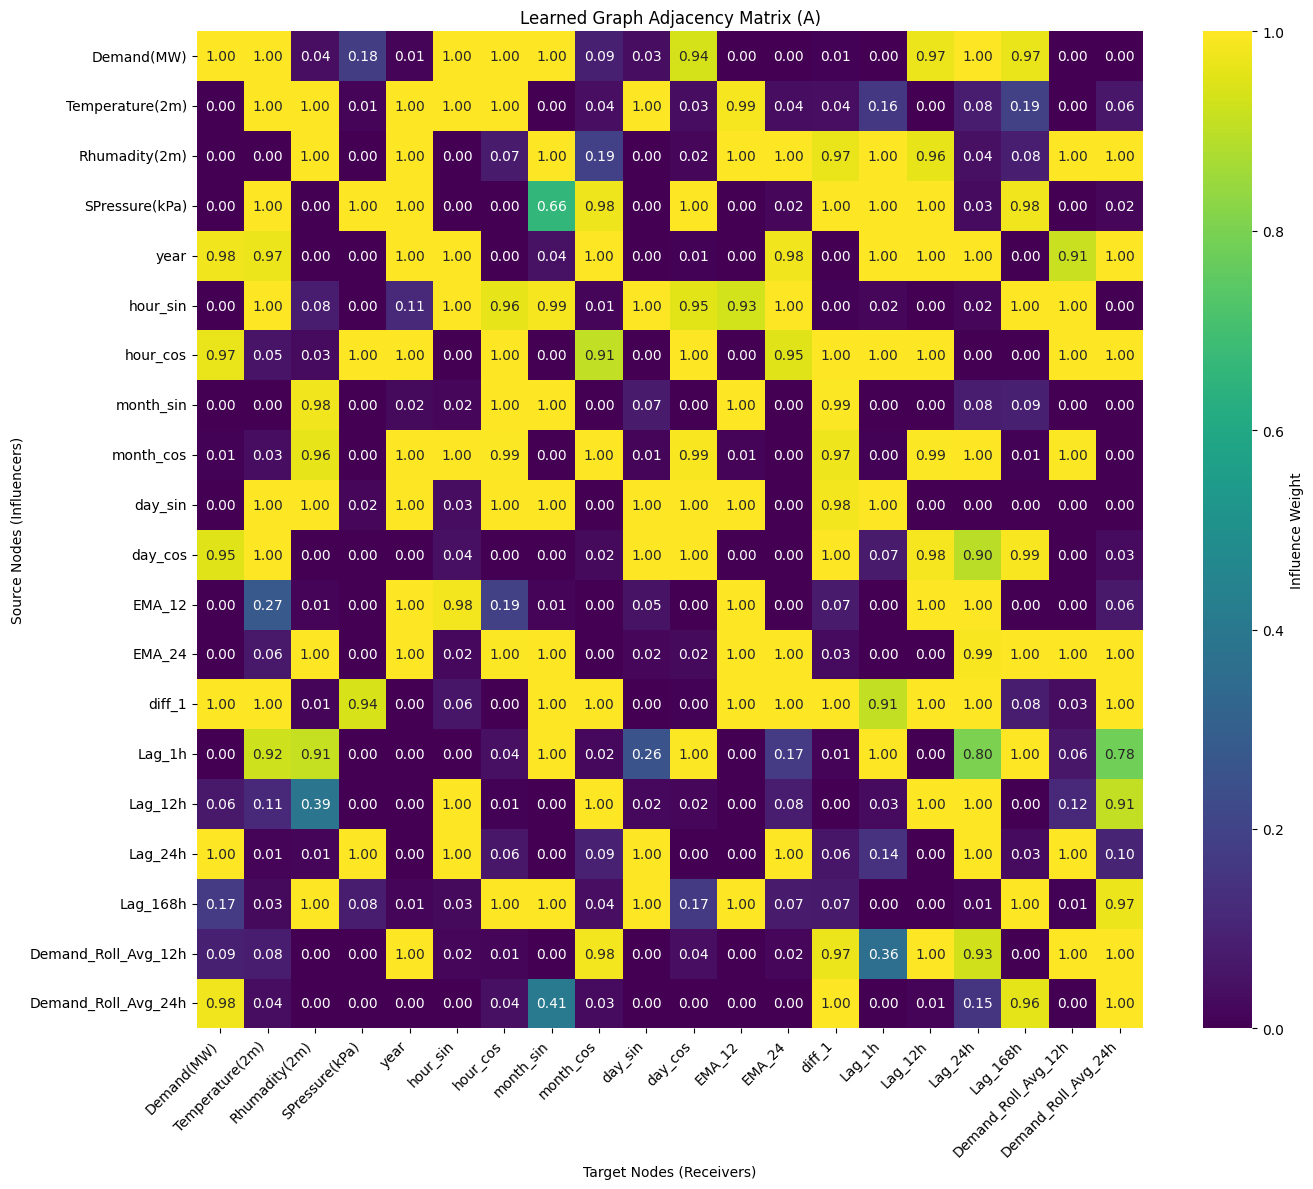

In [8]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # # --- Load dataset (unscaled) ---
    # dataset = ISO_NE(
    #     csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
    #     T_in=72,
    #     T_out=240,
    #     lag_hours=[24, 168],
    # )
    # --- Load dataset (unscaled) ---
    # dataset = ISO_NE(
    #     csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
    #     T_in=72,
    #     T_out=240,
    #     lag_hours=[1,2,6,12,24,168], # Updated lag_hours (change if necessary)
    # )
    # --- Load dataset (unscaled) ---
    dataset = BD_Dataset(
        csv_path="BangladeshData_2016_2024.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168],
        rolling_windows=[12,24],
    )
    # dataset = ISO_NE_Small(
    #     csv_path="ISO_NE_2013_2014.csv",
    #     T_in=72,
    #     T_out=240,
    #     lag_hours=[1,2,6,12,24,168],
    # )
    
    # dataset = AT(
    #     csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
    #     T_in=72,
    #     T_out=240,
    #     lag_hours=[1,12,24,168],
    #     rolling_windows=[12,24]
    # )
    
    # dataset = NCENT_Dataset(
    #     csv_path="GLFN-TC/Datasets/NCENT-dataset/COAST.csv",
    #     T_in=72,
    #     T_out=240,
    #     lag_hours=[1,2,6,12,24,168],
    # )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "NCENT_GLFN_TC_MultiScale"
    
    state = torch.load("Final_Run/BD_GLFN_TC_GlobalLocal_best_model.pth", map_location="cpu")
    
    model.load_state_dict(state, strict=True)
    model.eval()
    
    with torch.no_grad():
        A = model.graph_learn()    
        A = A.cpu().numpy()
        
        # --- FIX 1: Transpose the matrix if Row=Target and Col=Source ---
        # If A[i,j] means "j influences i", and you want Y-axis to be Source,
        # you usually need to Transpose it so Row becomes Source.
        A = A.T

    # Insert this right after loading the dataset (before model)
    node_names = list(dataset.df_numeric.columns[:hparams["N"]])
    print("Node names:", node_names)  # Verify
    
    # UPDATED PLOTTING SECTION
    plt.figure(figsize=(14, 12))  # Increased size to make room for numbers
    sns.heatmap(
        A, 
        cmap="viridis", 
        annot=True,      # <--- Turns on the values inside pixels
        fmt=".2f",       # <--- Formats numbers to 2 decimal places (e.g. 0.45)
        xticklabels=node_names, 
        yticklabels=node_names,
        cbar_kws={'label': 'Influence Weight'} # Optional: Label the colorbar
    )
    
    plt.title("Learned Graph Adjacency Matrix (A)")
    plt.xlabel("Target Nodes (Receivers)")
    plt.ylabel("Source Nodes (Influencers)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    main() 

# # --- NEW SECTION: FILTERING ---
#     # Create a copy so we don't destroy the original A data
#     A_vis = A.copy()
    
#     # Set all values less than or equal to 0.8 to 0.0
#     A_vis[A_vis <= 0.8] = 0.0

#     # UPDATED PLOTTING SECTION
#     plt.figure(figsize=(14, 12)) 
#     sns.heatmap(
#         A,                 # <--- Pass the filtered matrix here
#         cmap="viridis", 
#         annot=True,      
#         fmt=".2f",      
#         xticklabels=node_names, 
#         yticklabels=node_names,
#         cbar_kws={'label': 'Influence Weight'},
#         vmin=0, vmax=1         # Optional: Fixes the color scale range to 0-1
#     )
    
#     plt.title("Learned Graph Adjacency Matrix (A > 0.8)")
#     plt.xlabel("Target Nodes (Receivers)")
#     plt.ylabel("Source Nodes (Influencers)")
#     plt.xticks(rotation=45, ha='right')
#     plt.yticks(rotation=0)
#     plt.tight_layout()
#     plt.show()

# if __name__ == "__main__":
#     main()

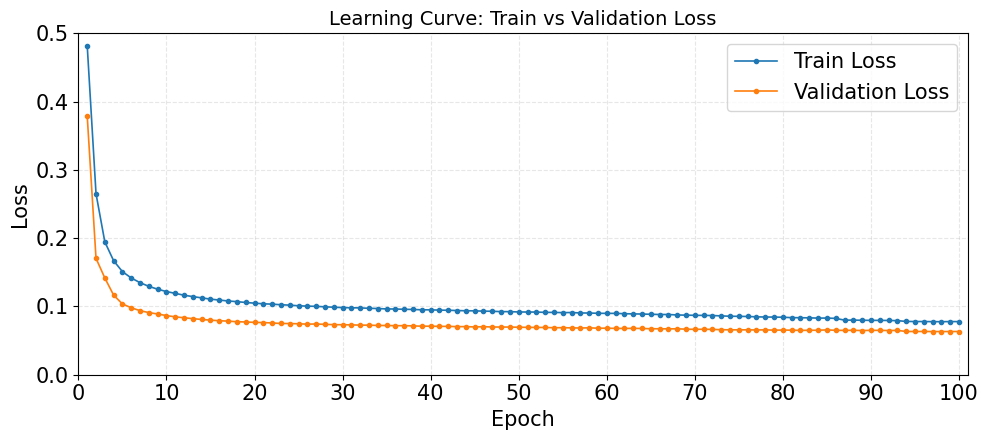

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = r"C:\Users\khurs\Downloads\AT_TR_GNN_MultiScale_Temporal_Graph_Learning_Train_Loss.csv"   # <-- your csv file
smooth_window = 0             # set >1 (e.g., 3 or 5) to smooth

df = pd.read_csv(csv_path)
df = df[["Step", "Train_Loss", "Validation_Loss"]].copy()
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")
df["Train_Loss"] = pd.to_numeric(df["Train_Loss"], errors="coerce")
df["Validation_Loss"] = pd.to_numeric(df["Validation_Loss"], errors="coerce")
df = df.dropna().sort_values("Step")

# Optional smoothing (rolling mean)
if smooth_window and smooth_window > 1:
    train_y = df["Train_Loss"].rolling(smooth_window, min_periods=1).mean()
    val_y   = df["Validation_Loss"].rolling(smooth_window, min_periods=1).mean()
else:
    train_y = df["Train_Loss"]
    val_y   = df["Validation_Loss"]

plt.figure(figsize=(10, 4.5))

plt.plot(
    df["Step"], train_y,
    color="tab:blue", marker="o", markersize=3,
    linewidth=1.2, label="Train Loss"
)
plt.plot(
    df["Step"], val_y,
    color="tab:orange", marker="o", markersize=3,
    linewidth=1.2, label="Validation Loss"
)

plt.title("Learning Curve: Train vs Validation Loss", fontsize=14)  # Increased title size
plt.xlabel("Epoch", fontsize=15)  # Increased x-axis label size
plt.ylabel("Loss", fontsize=15)  # Increased y-axis label size
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="upper right", fontsize=15)  # Increased legend size

# ---- axis ranges + tick steps ----
plt.xlim(0, 101)                               # 0..50 [web:47]
plt.xticks(np.arange(0, 101, 10), fontsize=15) # Increased x-tick size
plt.ylim(0, 0.45)                              # 0..0.5 [web:37]
plt.yticks(np.arange(0, 0.51, 0.1), fontsize=15)  # Increased y-tick size

plt.tight_layout()
plt.show()

In [22]:
import torch
from models import GLFN_TC_MultiScale  # Import your model class

# Define the model architecture
device = "cuda" if torch.cuda.is_available() else "cpu"
model = GLFN_TC_MultiScale(
    N=32,               # Number of nodes/features
    T_in=72,            # Input sequence length
    T_out=240,          # Output sequence length
    d=32,               # Input feature dimension
    hidden_dim=64,      # Hidden dimension
    GCN_Layer=5,        # Number of GCN layers
    dropout_gcn=0.2,    # Dropout for GCN
    dropout_temporal=0.2  # Dropout for temporal layers
).to(device)

# Load the saved model state
state_dict = torch.load("Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth", map_location=device)
model.load_state_dict(state_dict)

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully!")

RuntimeError: Error(s) in loading state_dict for GLFN_TC_MultiScale:
	Missing key(s) in state_dict: "graph_learn.v", "graph_learn.W", "temporal_conv.convs.18.weight", "temporal_conv.convs.18.bias", "temporal_conv.convs.19.weight", "temporal_conv.convs.19.bias", "temporal_conv.convs.20.weight", "temporal_conv.convs.20.bias", "temporal_conv.convs.21.weight", "temporal_conv.convs.21.bias", "temporal_conv.convs.22.weight", "temporal_conv.convs.22.bias", "temporal_conv.convs.23.weight", "temporal_conv.convs.23.bias", "temporal_conv.convs.24.weight", "temporal_conv.convs.24.bias", "temporal_conv.convs.25.weight", "temporal_conv.convs.25.bias", "temporal_conv.convs.26.weight", "temporal_conv.convs.26.bias", "temporal_conv.convs.27.weight", "temporal_conv.convs.27.bias", "temporal_conv.convs.28.weight", "temporal_conv.convs.28.bias", "temporal_conv.convs.29.weight", "temporal_conv.convs.29.bias", "temporal_conv.convs.30.weight", "temporal_conv.convs.30.bias", "temporal_conv.convs.31.weight", "